# Local CKPT Eval For AutoDL Transformer Runs

这份 notebook 用于**本地**评估从云端拉回来的 checkpoint。

默认行为：
- 扫描 `autodl_unplug_charger_transformer_fm/ckpt/epochs`
- 自动发现有多少个 checkpoint 就评多少个
- 可选同时纳入 `latest.pt / best.pt / best_success.pt`
- 评估完成后缓存到本地 json
- 自动画折线图，直观看不同 epoch 的 success rate / mean steps 变化


In [10]:
from pathlib import Path
import json
import re
import sys
import time
import os
os.environ["RLBENCH_ALLOW_IPYKERNEL"] = "1"

import matplotlib.pyplot as plt
import torch

CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/home/gjw/MyProjects/PointFlowMatch/autodl_unplug_charger_transformer_fm'),
]
PROJECT_ROOT = None
for cand in CANDIDATES:
    if (cand / 'lib').exists() and (cand / 'ckpt').exists():
        PROJECT_ROOT = cand
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate AutoDL transformer package root.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lib.train_utils import ExperimentConfig, load_model_for_eval, run_success_rate_eval


In [11]:
# User choices
CKPT_EPOCHS_DIR = PROJECT_ROOT / 'ckpt' / 'epochs'
INCLUDE_SPECIAL_CKPTS = True
SPECIAL_NAMES = ['latest.pt', 'best.pt', 'best_success.pt']
STRATEGY = 'fm'
PREFER_EMA = True

EVAL_EPISODES = 100
EVAL_SEED = 1234
SUCCESS_MAX_STEPS = 200
HEADLESS = True
FORCE_REEVAL = False

RESULTS_JSON = PROJECT_ROOT / 'ckpt' / 'local_eval_results.json'
PLOT_FIGSIZE = (10, 4)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CKPT_EPOCHS_DIR =', CKPT_EPOCHS_DIR)
print('RESULTS_JSON =', RESULTS_JSON)
print('EVAL_SEED =', EVAL_SEED)


PROJECT_ROOT = /home/gjw/MyProjects/autodl_unplug_charger_transformer_fm
CKPT_EPOCHS_DIR = /home/gjw/MyProjects/autodl_unplug_charger_transformer_fm/ckpt/epochs
RESULTS_JSON = /home/gjw/MyProjects/autodl_unplug_charger_transformer_fm/ckpt/local_eval_results.json
EVAL_SEED = 1234


In [12]:
# # Optional: evaluate one specific checkpoint only
# SINGLE_CKPT_PATH = None
# # Example:
SINGLE_CKPT_PATH = PROJECT_ROOT / 'ckpt' / 'epochs' / 'epoch_1050.pt'
# # SINGLE_CKPT_PATH = PROJECT_ROOT / 'ckpt' / 'latest.pt'

print('SINGLE_CKPT_PATH =', SINGLE_CKPT_PATH)


SINGLE_CKPT_PATH = /home/gjw/MyProjects/autodl_unplug_charger_transformer_fm/ckpt/epochs/epoch_1050.pt


In [13]:
def payload_cfg_to_experiment_cfg(payload_cfg: dict) -> ExperimentConfig:
    cfg_dict = dict(payload_cfg)
    cfg_dict.update({
        'seed': int(EVAL_SEED),
        'wandb_enable': False,
        'wandb_mode': 'disabled',
        'success_selection_every_epochs': 0,
        'success_selection_episodes': 0,
        'standard_eval_episodes': 0,
        'ckpt_root': PROJECT_ROOT / 'ckpt',
    })
    return ExperimentConfig(**cfg_dict)


def extract_epoch_from_path(path: Path, payload: dict) -> int | None:
    completed_epoch = payload.get('completed_epoch')
    if completed_epoch is not None:
        try:
            return int(completed_epoch) + 1
        except Exception:
            pass
    match = re.search(r'epoch_(\d+)', path.name)
    if match:
        return int(match.group(1))
    return None


def discover_checkpoints(epochs_dir: Path, include_special: bool = True):
    if not epochs_dir.exists():
        raise FileNotFoundError(f'Checkpoint epochs dir does not exist: {epochs_dir}')
    records = []
    for ckpt_path in sorted(epochs_dir.glob('*.pt')):
        payload = torch.load(ckpt_path, map_location='cpu')
        records.append({
            'label': ckpt_path.stem,
            'kind': 'periodic',
            'path': str(ckpt_path),
            'epoch': extract_epoch_from_path(ckpt_path, payload),
            'payload': payload,
        })
    if include_special:
        run_dir = epochs_dir.parent
        for name in SPECIAL_NAMES:
            ckpt_path = run_dir / name
            if ckpt_path.exists():
                payload = torch.load(ckpt_path, map_location='cpu')
                records.append({
                    'label': ckpt_path.stem,
                    'kind': 'special',
                    'path': str(ckpt_path),
                    'epoch': extract_epoch_from_path(ckpt_path, payload),
                    'payload': payload,
                })
    records.sort(key=lambda row: (10**9 if row['epoch'] is None else row['epoch'], row['label']))
    return records


def load_cached_results(path: Path):
    if not path.exists():
        return {}
    return json.loads(path.read_text())


def save_cached_results(path: Path, results: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(results, indent=2, ensure_ascii=False))


def eval_single_checkpoint(record: dict):
    payload = record['payload']
    cfg = payload_cfg_to_experiment_cfg(payload['cfg'])
    model, loaded_payload = load_model_for_eval(cfg, STRATEGY, record['path'], prefer_ema=PREFER_EMA)
    start = time.perf_counter()
    summary = run_success_rate_eval(
        model,
        cfg,
        num_episodes=int(EVAL_EPISODES),
        max_steps=int(SUCCESS_MAX_STEPS),
        headless=bool(HEADLESS),
        show_progress=True,
        progress_desc=f"eval {record['label']}",
    )
    elapsed = time.perf_counter() - start
    successes = int(sum(int(bool(row.get('success'))) for row in summary['episode_records']))
    return {
        'label': record['label'],
        'kind': record['kind'],
        'path': record['path'],
        'epoch': record['epoch'],
        'completed_epoch': payload.get('completed_epoch'),
        'best_metric': payload.get('best_metric'),
        'best_epoch': payload.get('best_epoch'),
        'best_success_rate': payload.get('best_success_rate'),
        'best_success_epoch': payload.get('best_success_epoch'),
        'success_rate': float(summary['success_rate']),
        'mean_steps': float(summary['mean_steps']),
        'num_successes': successes,
        'num_episodes': int(len(summary['episode_records'])),
        'duration_sec': float(elapsed),
        'episode_records': summary['episode_records'],
    }


def print_eval_table(results):
    print(f"{'label':<20} {'epoch':>8} {'kind':<10} {'succ':>8} {'mean_steps':>12} {'dur_s':>8}")
    for row in results:
        epoch = 'NA' if row['epoch'] is None else str(row['epoch'])
        print(f"{row['label']:<20} {epoch:>8} {row['kind']:<10} {row['success_rate']:>8.3f} {row['mean_steps']:>12.2f} {row['duration_sec']:>8.1f}")


In [14]:
# # Optional: visualize one checkpoint in the simulator
# VISUAL_CKPT_PATH = PROJECT_ROOT / 'ckpt' / 'epochs' / 'epoch_0400.pt'
# VISUAL_EPISODES = 1
# VISUAL_MAX_STEPS = 200
# VISUAL_PREFER_EMA = True
# VISUAL_SHOW_PROGRESS = True
# VISUAL_HEADLESS = False

# # Example:
# # VISUAL_CKPT_PATH = PROJECT_ROOT / 'ckpt' / 'epochs' / 'epoch_0100.pt'
# # VISUAL_CKPT_PATH = PROJECT_ROOT / 'ckpt' / 'latest.pt'

# print('VISUAL_CKPT_PATH =', VISUAL_CKPT_PATH)


In [ ]:
ckpt_records = discover_checkpoints(CKPT_EPOCHS_DIR, include_special=INCLUDE_SPECIAL_CKPTS)
print('discovered checkpoints:', len(ckpt_records))
for row in ckpt_records:
    print({
        'label': row['label'],
        'kind': row['kind'],
        'epoch': row['epoch'],
        'path': row['path'],
    })


In [ ]:
# if SINGLE_CKPT_PATH is None:
#     print('SINGLE_CKPT_PATH is None; skip single-checkpoint eval cell.')
# else:
#     single_ckpt_path = Path(SINGLE_CKPT_PATH)
#     if not single_ckpt_path.exists():
#         raise FileNotFoundError(f'Single checkpoint does not exist: {single_ckpt_path}')
#     single_payload = torch.load(single_ckpt_path, map_location='cpu')
#     single_record = {
#         'label': single_ckpt_path.stem,
#         'kind': 'single_manual',
#         'path': str(single_ckpt_path),
#         'epoch': extract_epoch_from_path(single_ckpt_path, single_payload),
#         'payload': single_payload,
#     }
#     cache_key = f"{single_record['path']}::episodes={EVAL_EPISODES}::max_steps={SUCCESS_MAX_STEPS}::ema={int(PREFER_EMA)}::seed={int(EVAL_SEED)}"
#     cached = load_cached_results(RESULTS_JSON)
#     if (not FORCE_REEVAL) and cache_key in cached:
#         single_result = cached[cache_key]
#         print(f"cache hit: {single_record['label']}")
#     else:
#         single_result = eval_single_checkpoint(single_record)
#         cached[cache_key] = single_result
#         save_cached_results(RESULTS_JSON, cached)

#     print_eval_table([single_result])
#     print('single_result =')
#     print(json.dumps({k: v for k, v in single_result.items() if k != 'episode_records'}, indent=2, ensure_ascii=False))


In [ ]:
# Standalone eval cell for epoch_0800.pt
from pathlib import Path
import json
import sys
import time
import torch

# auto-locate package root
CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/home/gjw/MyProjects/PointFlowMatch/autodl_unplug_charger_transformer_fm'),
]
PROJECT_ROOT = None
for cand in CANDIDATES:
    if (cand / 'lib').exists() and (cand / 'ckpt').exists():
        PROJECT_ROOT = cand
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate AutoDL transformer package root.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lib.train_utils import ExperimentConfig, load_model_for_eval, run_success_rate_eval

CKPT_PATH = PROJECT_ROOT / 'ckpt' / 'epochs' / 'epoch_0700.pt'
STRATEGY = 'fm'
EVAL_EPISODES = 100
SUCCESS_MAX_STEPS = 200
PREFER_EMA = True
HEADLESS = True
SHOW_PROGRESS = True

if not CKPT_PATH.exists():
    raise FileNotFoundError(f'Checkpoint not found: {CKPT_PATH}')

payload = torch.load(CKPT_PATH, map_location='cpu')

cfg_dict = dict(payload['cfg'])
cfg_dict.update({
    'wandb_enable': False,
    'wandb_mode': 'disabled',
    'success_selection_every_epochs': 0,
    'success_selection_episodes': 0,
    'standard_eval_episodes': 0,
    'ckpt_root': PROJECT_ROOT / 'ckpt',
})
cfg = ExperimentConfig(**cfg_dict)

model, _ = load_model_for_eval(
    cfg,
    STRATEGY,
    CKPT_PATH,
    prefer_ema=PREFER_EMA,
)

start = time.perf_counter()
summary = run_success_rate_eval(
    model,
    cfg,
    num_episodes=int(EVAL_EPISODES),
    max_steps=int(SUCCESS_MAX_STEPS),
    headless=bool(HEADLESS),
    show_progress=bool(SHOW_PROGRESS),
    progress_desc='epoch_0700 eval',
)
elapsed = time.perf_counter() - start

result = {
    'ckpt': str(CKPT_PATH),
    'success_rate': float(summary['success_rate']),
    'mean_steps': float(summary['mean_steps']),
    'num_episodes': int(summary['num_episodes']),
    'duration_sec': float(elapsed),
}
print(json.dumps(result, indent=2, ensure_ascii=False))


RuntimeError: Launching RLBench/CoppeliaSim inside an ipykernel/Jupyter process is unstable in this environment and can crash the kernel with Qt thread errors. Run the evaluation from a standalone Python process instead, e.g. `python scripts/eval_checkpoint.py --ckpt-path ...`, or set `RLBENCH_ALLOW_IPYKERNEL=1` if you want to bypass this guard.

In [ ]:
# if VISUAL_CKPT_PATH is None:
#     print('VISUAL_CKPT_PATH is None; skip visual rollout cell.')
# else:
#     visual_ckpt_path = Path(VISUAL_CKPT_PATH)
#     if not visual_ckpt_path.exists():
#         raise FileNotFoundError(f'Visual checkpoint does not exist: {visual_ckpt_path}')
#     visual_payload = torch.load(visual_ckpt_path, map_location='cpu')
#     visual_cfg = payload_cfg_to_experiment_cfg(visual_payload['cfg'])
#     visual_model, _ = load_model_for_eval(
#         visual_cfg,
#         STRATEGY,
#         visual_ckpt_path,
#         prefer_ema=bool(VISUAL_PREFER_EMA),
#     )
#     visual_start = time.perf_counter()
#     visual_summary = run_success_rate_eval(
#         visual_model,
#         visual_cfg,
#         num_episodes=int(VISUAL_EPISODES),
#         max_steps=int(VISUAL_MAX_STEPS),
#         headless=bool(VISUAL_HEADLESS),
#         show_progress=bool(VISUAL_SHOW_PROGRESS),
#         progress_desc=f"visual {visual_ckpt_path.stem}",
#     )
#     visual_elapsed = time.perf_counter() - visual_start
#     print('visual eval finished in', round(visual_elapsed, 2), 'sec')
#     print(json.dumps({
#         'ckpt': str(visual_ckpt_path),
#         'success_rate': float(visual_summary['success_rate']),
#         'mean_steps': float(visual_summary['mean_steps']),
#         'num_episodes': int(visual_summary['num_episodes']),
#         'duration_sec': float(visual_elapsed),
#     }, indent=2, ensure_ascii=False))


In [ ]:
cached = load_cached_results(RESULTS_JSON)
results = []
for record in ckpt_records:
    cache_key = f"{record['path']}::episodes={EVAL_EPISODES}::max_steps={SUCCESS_MAX_STEPS}::ema={int(PREFER_EMA)}::seed={int(EVAL_SEED)}"
    if (not FORCE_REEVAL) and cache_key in cached:
        result = cached[cache_key]
        print(f"cache hit: {record['label']}")
    else:
        result = eval_single_checkpoint(record)
        cached[cache_key] = result
        save_cached_results(RESULTS_JSON, cached)
    results.append(result)

print_eval_table(results)


eval epoch_0100:   0%|          | 0/50 [00:00<?, ?it/s]

eval epoch_0100: episode=0 starting
eval epoch_0100: episode=0 heartbeat step=50
eval epoch_0100: episode=0 heartbeat step=100
eval epoch_0100: episode=1 starting
eval epoch_0100: episode=1 heartbeat step=50
eval epoch_0100: episode=1 heartbeat step=100
eval epoch_0100: episode=2 starting
eval epoch_0100: episode=2 heartbeat step=50
eval epoch_0100: episode=2 heartbeat step=100
eval epoch_0100: episode=3 starting
eval epoch_0100: episode=3 heartbeat step=50
eval epoch_0100: episode=3 heartbeat step=100
eval epoch_0100: episode=4 starting
eval epoch_0100: episode=4 heartbeat step=50
eval epoch_0100: episode=4 heartbeat step=100
eval epoch_0100: episode=5 starting
eval epoch_0100: episode=5 heartbeat step=50
eval epoch_0100: episode=5 heartbeat step=100
eval epoch_0100: episode=6 starting
eval epoch_0100: episode=6 heartbeat step=50
eval epoch_0100: episode=6 heartbeat step=100
eval epoch_0100: episode=7 starting
eval epoch_0100: episode=7 heartbeat step=50
eval epoch_0100: episode=7 hea



Error: signal 11:

/home/gjw/CoppeliaSim/libcoppeliaSim.so.1(_Z11_segHandleri+0x30)[0x755c1f50aae0]
/lib/x86_64-linux-gnu/libc.so.6(+0x42520)[0x755db9642520]
[0x755c042dc611]


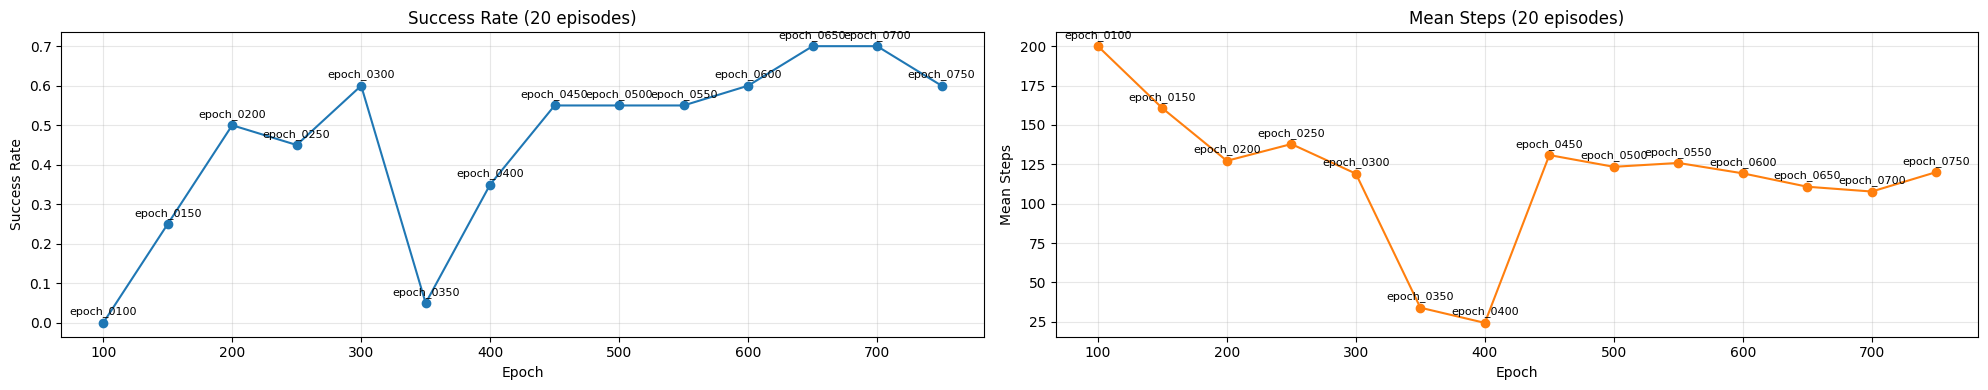

In [ ]:
if not results:
    raise RuntimeError('No evaluation results available.')

plot_rows = [row for row in results if row['epoch'] is not None]
if not plot_rows:
    raise RuntimeError('No checkpoint has a valid epoch for plotting.')

plot_rows = sorted(plot_rows, key=lambda row: (row['epoch'], row['label']))
epochs = [row['epoch'] for row in plot_rows]
success_rates = [row['success_rate'] for row in plot_rows]
mean_steps = [row['mean_steps'] for row in plot_rows]
labels = [row['label'] for row in plot_rows]

fig, axes = plt.subplots(1, 2, figsize=(PLOT_FIGSIZE[0] * 2, PLOT_FIGSIZE[1]))

axes[0].plot(epochs, success_rates, marker='o')
for x, y, label in zip(epochs, success_rates, labels):
    axes[0].annotate(label, (x, y), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
axes[0].set_title(f'Success Rate ({EVAL_EPISODES} episodes)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Success Rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, mean_steps, marker='o', color='tab:orange')
for x, y, label in zip(epochs, mean_steps, labels):
    axes[1].annotate(label, (x, y), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
axes[1].set_title(f'Mean Steps ({EVAL_EPISODES} episodes)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Steps')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


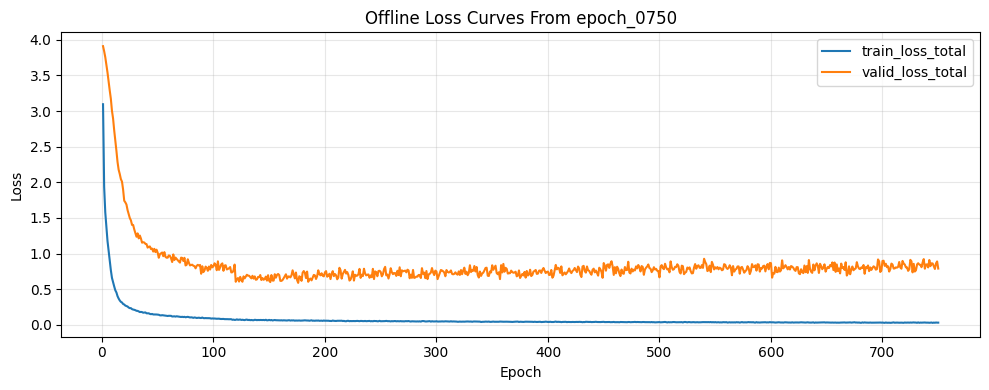

In [ ]:
# Optional: plot offline train/valid curves from the latest available checkpoint payload history.
reference = None
for row in reversed(ckpt_records):
    if row['payload'].get('train_loss_history'):
        reference = row
        break

if reference is None:
    print('No train/valid history found in checkpoint payloads.')
else:
    payload = reference['payload']
    train_hist = payload.get('train_loss_history') or []
    valid_hist = payload.get('valid_loss_history') or []
    epochs = list(range(1, len(train_hist) + 1))
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_hist, label='train_loss_total')
    if valid_hist:
        valid_epochs = [i + 1 for i, v in enumerate(valid_hist) if v is not None]
        valid_values = [v for v in valid_hist if v is not None]
        plt.plot(valid_epochs, valid_values, label='valid_loss_total')
    plt.title(f"Offline Loss Curves From {reference['label']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
